In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque, namedtuple
import random

# Set common seed
seed = 100
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# Environment setup
env = gym.make('Acrobot-v1')
state, info = env.reset(seed=seed)
env.action_space.seed(seed)
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Hyperparameters
REPLAY_MEMORY_SIZE = 10000
BATCH_SIZE = 32
GAMMA = 0.99
TARGET_UPDATE_FREQ = 100
LEARNING_RATE = 0.00025
RMS_DECAY = 0.95
RMS_MOMENTUM = 0.95
RMS_EPSILON = 0.01
EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_DECAY_STEPS = 2000
SEQUENCE_LENGTH = 4

Using device: cuda


# DQN

In [2]:
Experience = namedtuple('Experience', field_names=['state', 'action', 'reward', 'next_state', 'done'])

class QNetwork(nn.Module):
    def __init__(self):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [3]:

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append(Experience(state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


In [4]:
class DQNAgent:
    def __init__(self):
        self.policy_net = QNetwork().to(device)
        self.target_net = QNetwork().to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.RMSprop(
            self.policy_net.parameters(),
            lr=LEARNING_RATE,
            alpha=RMS_DECAY,
            momentum=RMS_MOMENTUM,
            eps=RMS_EPSILON,
            centered=False
        )

        self.memory = ReplayMemory(REPLAY_MEMORY_SIZE)
        self.step_count = 0

    def select_action(self, state, epsilon):
        state = torch.FloatTensor(state).unsqueeze(0).to(device)

        if random.random() > epsilon:
            with torch.no_grad():
                return self.policy_net(state).max(1)[1].item()
        else:
            return random.randrange(action_size)

    def optimize_model(self):
        if len(self.memory) < BATCH_SIZE:
            return

        experiences = self.memory.sample(BATCH_SIZE)
        batch = Experience(*zip(*experiences))

        state_batch = torch.FloatTensor(np.array(batch.state)).to(device)
        action_batch = torch.LongTensor(np.array(batch.action)).unsqueeze(1).to(device)
        reward_batch = torch.FloatTensor(np.array(batch.reward)).unsqueeze(1).to(device)
        next_state_batch = torch.FloatTensor(np.array(batch.next_state)).to(device)
        done_batch = torch.FloatTensor(np.array(batch.done)).unsqueeze(1).to(device)

        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        with torch.no_grad():
            next_state_values = self.target_net(next_state_batch).max(1)[0].unsqueeze(1)

        expected_state_action_values = torch.where(
            done_batch == 1,
            reward_batch,
            reward_batch + GAMMA * next_state_values
        )

        loss = nn.SmoothL1Loss()(state_action_values, expected_state_action_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1

        if self.step_count % TARGET_UPDATE_FREQ == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

In [5]:
def train_dqn(num_episodes=500, max_steps=500):
    agent = DQNAgent()
    scores = []
    total_steps = 0
    epoch_size = 10
    epoch_scores = []

    print(f"Starting DQN training for Acrobot-v1")

    for episode in range(1, num_episodes + 1):
        state, _ = env.reset()
        total_reward = 0

        for t in range(max_steps):
            decay_progress = min(total_steps / EPSILON_DECAY_STEPS, 1.0)
            current_epsilon = EPSILON_START - decay_progress * (EPSILON_START - EPSILON_END)
            epsilon = max(EPSILON_END, current_epsilon)

            action = agent.select_action(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.memory.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward
            total_steps += 1

            agent.optimize_model()

            if done:
                break

        scores.append(total_reward)

        # Calculate epoch scores
        if episode % epoch_size == 0:
            epoch_scores.append(np.mean(scores[-epoch_size:]))
            print(f"Epoch {len(epoch_scores)}, Average score: {epoch_scores[-1]:.2f}, Epsilon: {epsilon:.3f}, steps: {total_steps}")

        if episode % 100 == 0:
            avg_score = np.mean(scores[-100:])
            print(f"Episode {episode}\tAverage Score (100 episodes): {avg_score:.2f}")

        # Acrobot-v1 is considered solved when average reward over 100 episodes is >= -100
        if episode >= 100 and np.mean(scores[-100:]) >= -100.0:
            print(f"\nEnvironment solved in {episode} episodes. Average Score (100 episodes): {np.mean(scores[-100:]):.2f}")
            break

    return scores, epoch_scores

# GRU DQN IMPLEMENTATION

In [6]:
GRUExperience = namedtuple('GRUExperience', field_names=['states', 'actions', 'rewards', 'next_states', 'dones'])

class GRUQNetwork(nn.Module):
    """GRU-based Q-Network"""
    def __init__(self, state_size, action_size, hidden_size=64):
        super(GRUQNetwork, self).__init__()
        self.gru = nn.GRU(
            input_size=state_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, action_size)

    def forward(self, x):
        # Run GRU and get the final hidden state
        out, _ = self.gru(x)
        # Use the last output for prediction
        q_values = self.fc(out[:, -1])
        return q_values

In [7]:
class TrajectoryReplayMemory:
    def __init__(self, capacity, sequence_length=SEQUENCE_LENGTH):
        self.memory = deque(maxlen=capacity)
        self.sequence_length = sequence_length

        # Temporary buffers for current sequence
        self.current_states = []
        self.current_actions = []
        self.current_rewards = []
        self.current_next_states = []
        self.current_dones = []

    def push(self, state, action, reward, next_state, done):
        self.current_states.append(state)
        self.current_actions.append(action)
        self.current_rewards.append(reward)
        self.current_next_states.append(next_state)
        self.current_dones.append(done)

        if len(self.current_states) == self.sequence_length or done:
            if len(self.current_states) >= 2:
                while len(self.current_states) < self.sequence_length:
                    self.current_states.append(np.zeros_like(state))
                    self.current_actions.append(0)
                    self.current_rewards.append(0)
                    self.current_next_states.append(np.zeros_like(next_state))
                    self.current_dones.append(True)

                self.memory.append(GRUExperience(
                    states=np.array(self.current_states),
                    actions=np.array(self.current_actions),
                    rewards=np.array(self.current_rewards),
                    next_states=np.array(self.current_next_states),
                    dones=np.array(self.current_dones)
                ))

            self.current_states = []
            self.current_actions = []
            self.current_rewards = []
            self.current_next_states = []
            self.current_dones = []

            if done:
                return

    def sample(self, batch_size):
        return random.sample(self.memory, min(batch_size, len(self.memory)))

    def __len__(self):
        return len(self.memory)


In [8]:
class GRUDQNAgent:
    def __init__(self):
        self.state_size = state_size
        self.action_size = action_size
        self.sequence_length = SEQUENCE_LENGTH

        self.policy_net = GRUQNetwork(state_size, action_size).to(device)
        self.target_net = GRUQNetwork(state_size, action_size).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.RMSprop(
            self.policy_net.parameters(),
            lr=LEARNING_RATE,
            alpha=RMS_DECAY,
            eps=RMS_EPSILON,
            momentum=RMS_MOMENTUM,
            centered=False
        )

        self.memory = TrajectoryReplayMemory(REPLAY_MEMORY_SIZE, self.sequence_length)

        self.state_buffer = deque(maxlen=self.sequence_length)
        self.reset_state_buffer()

        # Step counter
        self.steps_done = 0

    def reset_state_buffer(self):
        """Reset the state buffer with zeros"""
        self.state_buffer = deque(maxlen=self.sequence_length)
        for _ in range(self.sequence_length):
            self.state_buffer.append(np.zeros(self.state_size))

    def update_state_buffer(self, state):
        """Add new state to the buffer"""
        self.state_buffer.append(state)

    def select_action(self, epsilon):
        """Select an action using epsilon-greedy policy"""
        if random.random() > epsilon:
            with torch.no_grad():
                # Convert state buffer to tensor
                states = np.array(list(self.state_buffer))
                states_tensor = torch.FloatTensor(states).unsqueeze(0).to(device)
                return self.policy_net(states_tensor).max(1)[1].item()
        else:
            return random.randrange(self.action_size)

    def optimize_model(self):
        if len(self.memory) < BATCH_SIZE:
            return

        experiences = self.memory.sample(BATCH_SIZE)

        states_batch = torch.FloatTensor(np.array([e.states for e in experiences])).to(device)
        actions_batch = torch.LongTensor(np.array([e.actions[-1] for e in experiences])).unsqueeze(1).to(device)
        rewards_batch = torch.FloatTensor(np.array([e.rewards[-1] for e in experiences])).unsqueeze(1).to(device)
        next_states_batch = torch.FloatTensor(np.array([e.next_states for e in experiences])).to(device)
        dones_batch = torch.FloatTensor(np.array([e.dones[-1] for e in experiences])).unsqueeze(1).to(device)

        state_action_values = self.policy_net(states_batch).gather(1, actions_batch)

        with torch.no_grad():
            next_state_values = self.target_net(next_states_batch).max(1)[0].unsqueeze(1)

        expected_state_action_values = rewards_batch + (1 - dones_batch) * GAMMA * next_state_values

        loss = nn.SmoothL1Loss()(state_action_values, expected_state_action_values)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

        # Update target network
        self.steps_done += 1
        if self.steps_done % TARGET_UPDATE_FREQ == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

In [9]:
def train_gru_dqn(num_episodes=500, max_steps=500):
    agent = GRUDQNAgent()
    scores = []
    total_steps = 0
    epoch_size = 10
    epoch_scores = []

    print(f"Starting GRU DQN training for Acrobot-v1")

    for episode in range(1, num_episodes + 1):
        state, _ = env.reset()
        total_reward = 0

        agent.reset_state_buffer()
        agent.update_state_buffer(state)

        for t in range(max_steps):
            decay_progress = min(total_steps / EPSILON_DECAY_STEPS, 1.0)
            current_epsilon = EPSILON_START - decay_progress * (EPSILON_START - EPSILON_END)
            epsilon = max(EPSILON_END, current_epsilon)

            action = agent.select_action(epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.memory.push(state, action, reward, next_state, done)

            agent.update_state_buffer(next_state)

            state = next_state
            total_reward += reward
            total_steps += 1

            agent.optimize_model()

            if done:
                break

        scores.append(total_reward)

        # Calculate epoch scores
        if episode % epoch_size == 0:
            epoch_scores.append(np.mean(scores[-epoch_size:]))
            print(f"Epoch {len(epoch_scores)}, Average score: {epoch_scores[-1]:.2f}, Epsilon: {epsilon:.3f}, steps: {total_steps}")

        if episode % 100 == 0:
            avg_score = np.mean(scores[-100:])
            print(f"Episode {episode}\tAverage Score (100 episodes): {avg_score:.2f}")

        # Acrobot-v1 is considered solved when average reward over 100 episodes is >= -100
        if episode >= 100 and np.mean(scores[-100:]) >= -100.0:
            print(f"\nEnvironment solved in {episode} episodes. Average Score (100 episodes): {np.mean(scores[-100:]):.2f}")
            break

    return scores, epoch_scores

# MAIN EXECUTION


--- Running standard DQN ---
Starting DQN training for Acrobot-v1
Epoch 1, Average score: -388.30, Epsilon: 0.100, steps: 3889
Epoch 2, Average score: -203.10, Epsilon: 0.100, steps: 5930
Epoch 3, Average score: -204.70, Epsilon: 0.100, steps: 7987
Epoch 4, Average score: -310.90, Epsilon: 0.100, steps: 11105
Epoch 5, Average score: -265.60, Epsilon: 0.100, steps: 13771
Epoch 6, Average score: -193.10, Epsilon: 0.100, steps: 15712
Epoch 7, Average score: -150.50, Epsilon: 0.100, steps: 17227
Epoch 8, Average score: -160.50, Epsilon: 0.100, steps: 18842
Epoch 9, Average score: -132.00, Epsilon: 0.100, steps: 20172
Epoch 10, Average score: -124.30, Epsilon: 0.100, steps: 21425
Episode 100	Average Score (100 episodes): -213.30
Epoch 11, Average score: -129.10, Epsilon: 0.100, steps: 22726
Epoch 12, Average score: -145.60, Epsilon: 0.100, steps: 24192
Epoch 13, Average score: -109.70, Epsilon: 0.100, steps: 25299
Epoch 14, Average score: -111.90, Epsilon: 0.100, steps: 26428
Epoch 15, Ave

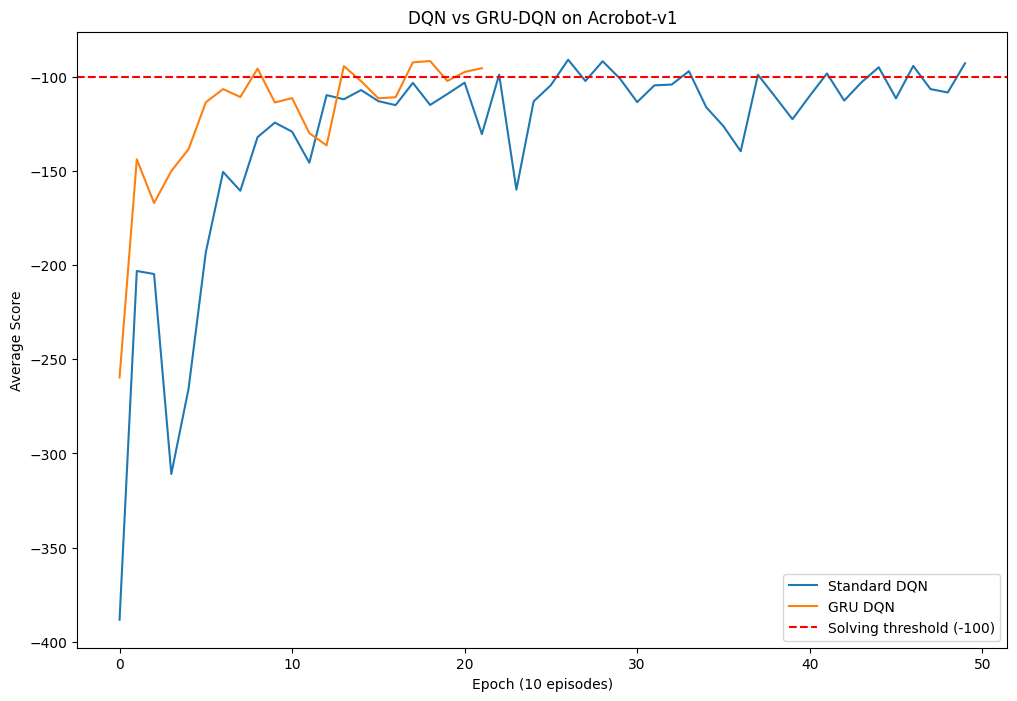

In [10]:
dqn_scores, dqn_epoch_scores = train_dqn(num_episodes=500, max_steps=500)

print("\n--- Running GRU DQN ---")
gru_scores, gru_epoch_scores = train_gru_dqn(num_episodes=500, max_steps=500)

plt.figure(figsize=(12, 8))
plt.plot(range(len(dqn_epoch_scores)), dqn_epoch_scores, label='Standard DQN')
plt.plot(range(len(gru_epoch_scores)), gru_epoch_scores, label='GRU DQN')
plt.title('DQN vs GRU-DQN on Acrobot-v1')
plt.xlabel('Epoch (10 episodes)')
plt.ylabel('Average Score')
plt.axhline(y=-100, color='r', linestyle='--', label='Solving threshold (-100)')
plt.legend()
plt.savefig('dqn_vs_gru_dqn_acrobot.png')
plt.show()

# Close the environment
env.close()